In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nelgiriyewithana/apple-quality")

print("Path to dataset files:", path)

c:\Users\yamaw\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 170k/170k [00:00<00:00, 519kB/s]

Extracting files...
Path to dataset files: C:\Users\yamaw\.cache\kagglehub\datasets\nelgiriyewithana\apple-quality\versions\1


In [4]:
import pandas as pd
import os

files = os.listdir(path)
print(files)

['apple_quality.csv']


In [5]:
csv_path = os.path.join(path, "apple_quality.csv")
df = pd.read_csv(csv_path)

df.head()

,A_id,Size,Weight,Sweetness,Crunchiness,Juiciness,Ripeness,Acidity,Quality
0,0.0,-3.970049,-2.512336,5.346330,-1.012009,1.844900,0.329840,-0.491590483,good
1,1.0,-1.195217,-2.839257,3.664059,1.588232,0.853286,0.867530,-0.722809367,good
2,2.0,-0.292024,-1.351282,-1.738429,-0.342616,2.838636,-0.038033,2.621636473,bad
3,3.0,-0.657196,-2.271627,1.324874,-0.097875,3.637970,-3.413761,0.790723217,good
4,4.0,1.364217,-1.296612,-0.384658,-0.553006,3.030874,-1.303849,0.501984036,good


In [6]:
# 欠損値を確認する
df.isnull().sum()

A_id           1
Size           1
Weight         1
Sweetness      1
Crunchiness    1
Juiciness      1
Ripeness       1
Acidity        0
Quality        1
dtype: int64

In [8]:
# 欠損値がある行を削除する
df = df.dropna()

print(df.isnull().sum())

A_id           0
Size           0
Weight         0
Sweetness      0
Crunchiness    0
Juiciness      0
Ripeness       0
Acidity        0
Quality        0
dtype: int64


In [9]:
print(df.dtypes)

A_id           float64
Size           float64
Weight         float64
Sweetness      float64
Crunchiness    float64
Juiciness      float64
Ripeness       float64
Acidity         object
Quality         object
dtype: object


In [10]:
# Acidityを数値型に変換
df["Acidity"] = df["Acidity"].astype(float)

# 分析に関係ないID列を削除
df = df.drop("A_id", axis=1)

print(df.dtypes)


Size           float64
Weight         float64
Sweetness      float64
Crunchiness    float64
Juiciness      float64
Ripeness       float64
Acidity        float64
Quality         object
dtype: object


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Size         4000 non-null   float64
 1   Weight       4000 non-null   float64
 2   Sweetness    4000 non-null   float64
 3   Crunchiness  4000 non-null   float64
 4   Juiciness    4000 non-null   float64
 5   Ripeness     4000 non-null   float64
 6   Acidity      4000 non-null   float64
 7   Quality      4000 non-null   object 
dtypes: float64(7), object(1)
memory usage: 281.2+ KB


In [12]:
df.describe()

,Size,Weight,Sweetness,Crunchiness,Juiciness,Ripeness,Acidity
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,-0.503015,-0.989547,-0.470479,0.985478,0.512118,0.498277,0.076877
std,1.928059,1.602507,1.943441,1.402757,1.930286,1.874427,2.110270
min,-7.151703,-7.149848,-6.894485,-6.055058,-5.961897,-5.864599,-7.010538
25%,-1.816765,-2.011770,-1.738425,0.062764,-0.801286,-0.771677,-1.377424
50%,-0.513703,-0.984736,-0.504758,0.998249,0.534219,0.503445,0.022609
75%,0.805526,0.030976,0.801922,1.894234,1.835976,1.766212,1.510493
max,6.406367,5.790714,6.374916,7.619852,7.364403,7.237837,7.404736


In [16]:
# 列名を日本語に変換
df = df.rename(columns={
    "Size": "サイズ",
    "Weight": "重さ",
    "Sweetness": "甘さ",
    "Crunchiness": "シャキシャキ感",
    "Juiciness": "ジューシーさ",
    "Ripeness": "熟度",
    "Acidity": "酸味",
    "Quality": "品質"
})

df.head()

,サイズ,重さ,甘さ,シャキシャキ感,ジューシーさ,熟度,酸味,品質
0,-3.970049,-2.512336,5.346330,-1.012009,1.844900,0.329840,-0.491590,good
1,-1.195217,-2.839257,3.664059,1.588232,0.853286,0.867530,-0.722809,good
2,-0.292024,-1.351282,-1.738429,-0.342616,2.838636,-0.038033,2.621636,bad
3,-0.657196,-2.271627,1.324874,-0.097875,3.637970,-3.413761,0.790723,good
4,1.364217,-1.296612,-0.384658,-0.553006,3.030874,-1.303849,0.501984,good


In [18]:
from sklearn.model_selection import train_test_split

# 品質を数値に変換
if df["品質"].dtype == "object":
    df["品質"] = df["品質"].map({"good": 1, "bad": 0})

# 特徴量（X）と目的変数（ｙ）に分ける
X = df.drop("品質", axis=1)
y = df["品質"]

# 80%を学習用、20%をテスト用に分割
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"学習用データ：{len(X_train)}件")
print(f"テスト用データ：{len(X_test)}件")

学習用データ：3200件
テスト用データ：800件


In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# モデルの作成
model_1 = RandomForestClassifier(random_state=42)

# 学習
model_1.fit(X_train, y_train)

# 予測
y_pred_1 = model_1.predict(X_test)

# スコア表示
print("【ランダムフォレストの予測結果】")
print(f"正解率： {accuracy_score(y_test, y_pred_1):.2f}%")


【ランダムフォレストの予測結果】
正解率： 0.90%


In [24]:
import pandas as pd

# 詳細レポートの表示
report_dict = classification_report(y_test, y_pred_1, target_names=["Bad(0)", "Good(1)"], output_dict=True)
report_df = pd.DataFrame(report_dict).T

print("model_1 詳細レポート")
display(report_df)


model_1 詳細レポート


,precision,recall,f1-score,support
Bad(0),0.903553,0.887781,0.895597,401.00000
Good(1),0.889163,0.904762,0.896894,399.00000
accuracy,0.896250,0.896250,0.896250,0.89625
macro avg,0.896358,0.896271,0.896246,800.00000
weighted avg,0.896376,0.896250,0.896244,800.00000


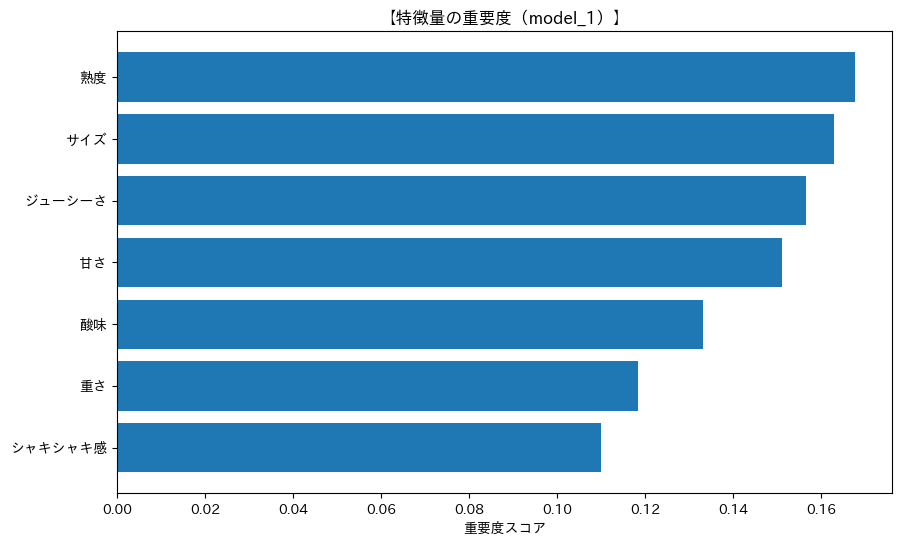

In [26]:
import matplotlib.pyplot as plt
import japanize_matplotlib
import numpy as np

# 特徴量の重要度を取得
importances = model_1.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)

# グラフの作成
plt.figure(figsize=(10, 6))
plt.title("【特徴量の重要度（model_1）】")
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("重要度スコア")
plt.show()

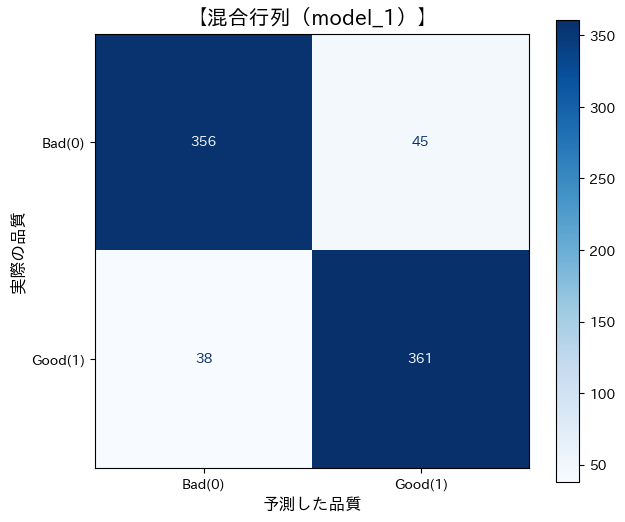

In [30]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 6))

disp = ConfusionMatrixDisplay.from_estimator(
    model_1,
    X_test,
    y_test,
    display_labels=["Bad(0)", "Good(1)"],
    cmap="Blues",
    ax=ax
)

plt.title("【混合行列（model_1）】", fontsize=15)
plt.xlabel("予測した品質", fontsize=12)
plt.ylabel("実際の品質", fontsize=12)

plt.show()

In [40]:
df_texture = df.copy()

# 熟度とシャキシャキ感を掛け合わせて「食べごろ指数」を作る
df_texture["食べ頃指数"] = df_texture["熟度"] * df_texture["シャキシャキ感"]

# データを分割
X_t = df_texture.drop("品質", axis=1)
y_t = df_texture["品質"]
X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(X_t, y_t, test_size=0.2, random_state=42)

# 学習
model_2 = RandomForestClassifier(random_state=42)
model_2.fit(X_train_t, y_train_t)

# 精度確認
acc_2 = model_2.score(X_test_t, y_test_t)
print(f"model_3(食べ頃指数追加)の正解率：{acc_2:.4f}")

model_3(食べ頃指数追加)の正解率：0.9075


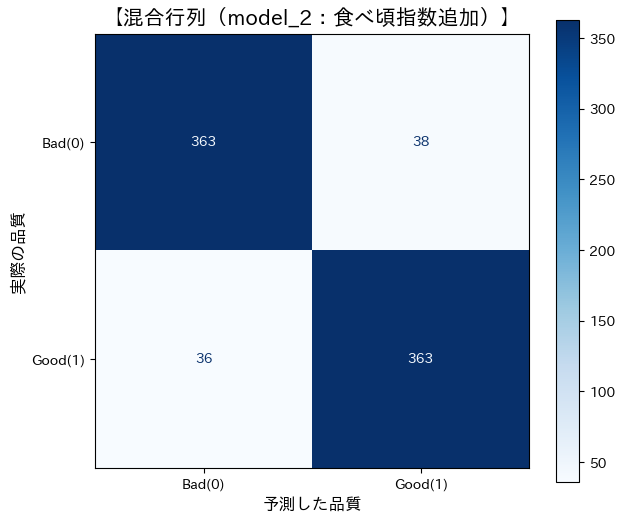

In [41]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 6))

disp = ConfusionMatrixDisplay.from_estimator(
    model_2,
    X_test_t,
    y_test_t,
    display_labels=["Bad(0)", "Good(1)"],
    cmap="Blues",
    ax=ax
)

plt.title("【混合行列（model_2：食べ頃指数追加）】", fontsize=15)
plt.xlabel("予測した品質", fontsize=12)
plt.ylabel("実際の品質", fontsize=12)

plt.show()

In [44]:
import lightgbm as lgb
from sklearn.metrics import accuracy_score

# LightGBMのデータセット作成
train_data = lgb.Dataset(X_train_t, label=y_train_t)

# パラメータの設定
params = {
    "objective": "binary",
    "metric": "binary_error",
    "verbose": "-1",
    "random_state": 42
}

# 学習
model_3 =lgb.train(params, train_data, num_boost_round=100)

# 予測
y_pred_prob = model_3.predict(X_test_t)
y_pred_3 = [1 if p >= 0.5 else 0 for p in y_pred_prob]

# スコア表示
acc_3 = accuracy_score(y_test_t, y_pred_3)
print(f"model_3(LightGBM)の正解率：{acc_3:.4f}")

model_3(LightGBM)の正解率：0.8988


In [46]:
# 1. model_3 (RF) の予測確率を出す
prob_rf = model_2.predict_proba(X_test_t)[:, 1]

# 2. model_4 (LGBM) の予測確率を出す
prob_lgb = model_3.predict(X_test_t)

# 3. 二つの「自信（確率）」を足して2で割る（平均をとる）
final_prob = (prob_rf + prob_lgb) / 2

# 4. 0.5を境に 0 か 1 に決める
y_pred_ensemble = [1 if p >= 0.5 else 0 for p in final_prob]

# 5. スコア確認
from sklearn.metrics import accuracy_score
acc_ensemble = accuracy_score(y_test_t, y_pred_ensemble)
print(f"アンサンブル後の正解率: {acc_ensemble:.4f}")

アンサンブル後の正解率: 0.9137


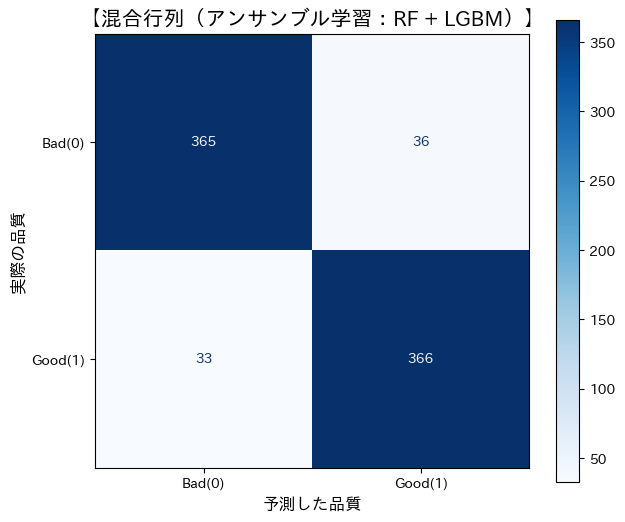

In [47]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_t, y_pred_ensemble)

# 表示
fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Bad(0)", "Good(1)"])
disp.plot(cmap="Blues", ax=ax)

plt.title("【混合行列（アンサンブル学習：RF + LGBM）】", fontsize=15)
plt.xlabel("予測した品質", fontsize=12)
plt.ylabel("実際の品質", fontsize=12)
plt.show()

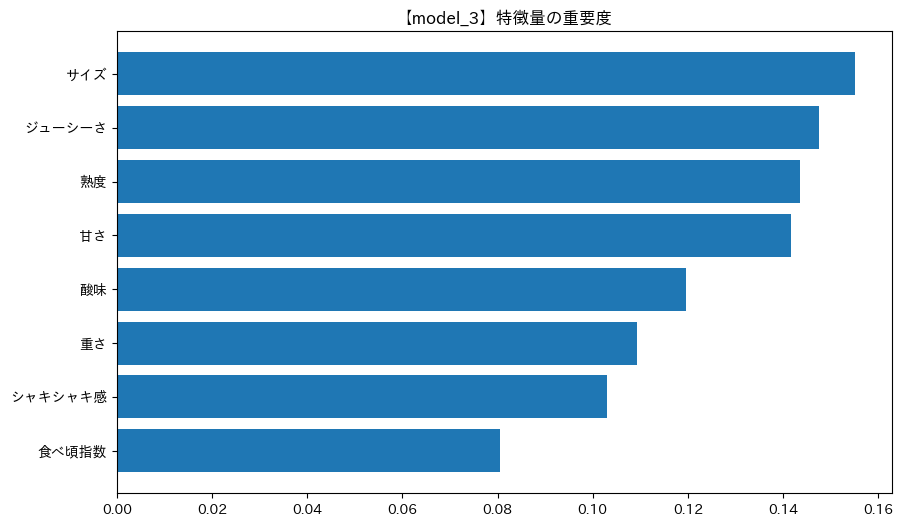

In [52]:
import pandas as pd
import matplotlib.pyplot as plt

importances = model_2.feature_importances_
feature_names = X_t.columns
feature_importance_df = pd.DataFrame({"特徴量": feature_names, "重要度": importances})
feature_importance_df = feature_importance_df.sort_values(by="重要度", ascending=True)

# グラフ表示
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df["特徴量"], feature_importance_df["重要度"])
plt.title("【model_3】特徴量の重要度")
plt.show()